# Transfer Learning (Aprendizado por Transferência) para Diagnóstico de Falhas

**Projeto:** Diagnóstico de Falhas em Rolamentos via CNN + Transformada Wavelet Contínua  
**Dataset:** Escalogramas CWT (CWRU - 4 classes: `normal`, `ball`, `inner_race`, `outer_race`)  
**Objetivo:** Executar experimentos de Transfer Learning com modelos pré-treinados no ImageNet (**ResNet-18**, **Inception-v3** e **EfficientNet-B0**) em blocos de código separados e independentes, invocando o módulo `src.transfer_learning`, conforme abordado no Referencial Teórico da Monografia (Seção 2.4 e Tabela 4).

---

## 1. Importação de Bibliotecas e Módulos do Projeto

In [1]:
import sys
from pathlib import Path

BASE_DIR = Path.cwd().parent
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Importar configurações e motor de Transfer Learning de src/
from src.config import NUM_EPOCHS, LEARNING_RATE
from src.transfer_learning import train_and_evaluate_transfer_model

from src.visualization import plot_training_curves, plot_confusion_matrix

# Dicionário global para consolidar todos os resultados
resultados = {}

## 2. Experimento 1: ResNet-18

Treinamento, curvas de aprendizado, relatório de classificação e matriz de confusão da **ResNet-18**.

[INFO] EXPERIMENTO TRANSFER LEARNING: RESNET18 | Freeze=False | Épocas=10 | LR=0.0001
Época [01/10] | Treino Loss: 0.0451 - Acc: 98.50% | Val Loss: 0.0006 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 01/10.
Época [02/10] | Treino Loss: 0.0061 - Acc: 99.88% | Val Loss: 0.0010 - Acc: 100.00% 
Época [03/10] | Treino Loss: 0.0019 - Acc: 99.96% | Val Loss: 0.0002 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 03/10.
Época [04/10] | Treino Loss: 0.0005 - Acc: 100.00% | Val Loss: 0.0001 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 04/10.
Época [05/10] | Treino Loss: 0.0002 - Acc: 100.00% | Val Loss: 0.0000 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 05/10.
Época [06/10] | Treino Loss: 0.0001 - Acc: 100.00% | Val Loss: 0.0000 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 06/10.
Época [07/10] | Treino Loss: 0.0002 - Acc: 100.00% | Val Loss: 0.0000 - Acc: 100.00% 
Época [08/10] | Treino Loss: 0.0153 - Acc: 99.60% | Val Loss: 0.0059 - Acc: 99.8

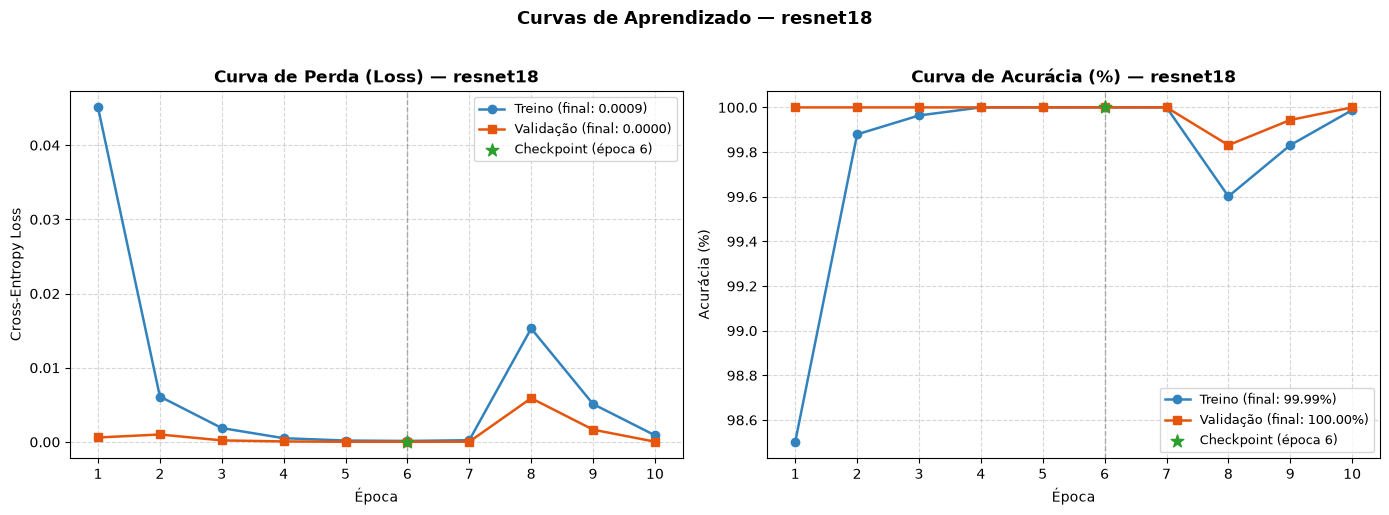

=== RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (RESNET-18) ===
              precision    recall  f1-score   support

        ball     1.0000    1.0000    1.0000       426
  inner_race     1.0000    1.0000    1.0000       426
      normal     1.0000    1.0000    1.0000       497
  outer_race     1.0000    1.0000    1.0000       427

    accuracy                         1.0000      1776
   macro avg     1.0000    1.0000    1.0000      1776
weighted avg     1.0000    1.0000    1.0000      1776



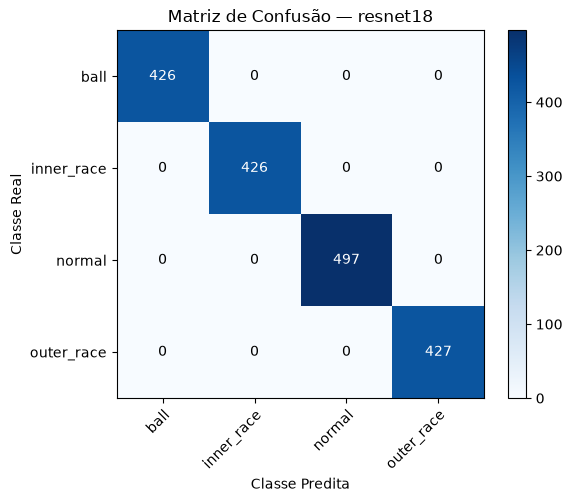

In [2]:
# Treinamento da ResNet-18
res_resnet = train_and_evaluate_transfer_model('resnet18', num_epochs=NUM_EPOCHS, lr=LEARNING_RATE, freeze=False)
resultados['resnet18'] = res_resnet

# --- 1. Curvas de Aprendizado ---
plot_training_curves(res_resnet['history'], 'resnet18',
                      save_path='../docs/images/training_curves_resnet.png')

# --- 2. Relatório de Classificação ---
print('=== RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (RESNET-18) ===')
print(classification_report(res_resnet['test_labels'], res_resnet['test_preds'], target_names=res_resnet['classes'], digits=4))

# --- 3. Matriz de Confusão ---
plot_confusion_matrix(res_resnet, 'resnet18')


## 3. Experimento 2: Inception-v3

Treinamento, curvas de aprendizado, relatório de classificação e matriz de confusão do **Inception-v3** (com imagens redimensionadas para $299 \times 299$).

[INFO] EXPERIMENTO TRANSFER LEARNING: INCEPTION_V3 | Freeze=False | Épocas=10 | LR=0.0001
Época [01/10] | Treino Loss: 0.0930 - Acc: 97.23% | Val Loss: 0.0011 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 01/10.
Época [02/10] | Treino Loss: 0.0042 - Acc: 99.94% | Val Loss: 0.0010 - Acc: 99.94% [CHECKPOINT] Modelo ótimo salvo na época 02/10.
Época [03/10] | Treino Loss: 0.0027 - Acc: 99.96% | Val Loss: 0.0002 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 03/10.
Época [04/10] | Treino Loss: 0.0084 - Acc: 99.72% | Val Loss: 0.0072 - Acc: 99.83% 
Época [05/10] | Treino Loss: 0.0131 - Acc: 99.55% | Val Loss: 0.0008 - Acc: 99.94% 
Época [06/10] | Treino Loss: 0.0045 - Acc: 99.86% | Val Loss: 0.0008 - Acc: 99.94% 
Época [07/10] | Treino Loss: 0.0018 - Acc: 99.96% | Val Loss: 0.0002 - Acc: 100.00% 
Época [08/10] | Treino Loss: 0.0012 - Acc: 99.96% | Val Loss: 0.0028 - Acc: 99.94% 
Época [09/10] | Treino Loss: 0.0002 - Acc: 100.00% | Val Loss: 0.0003 - Acc: 100.00% 
Época [1

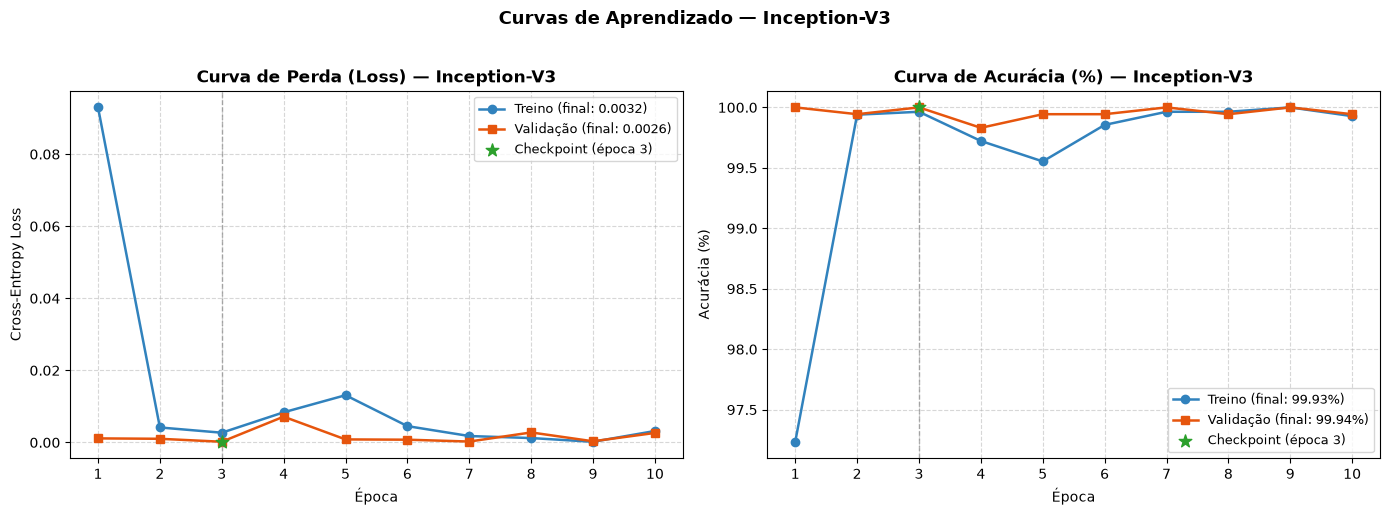

=== RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (INCEPTION-V3) ===
              precision    recall  f1-score   support

        ball     1.0000    1.0000    1.0000       426
  inner_race     1.0000    1.0000    1.0000       426
      normal     1.0000    1.0000    1.0000       497
  outer_race     1.0000    1.0000    1.0000       427

    accuracy                         1.0000      1776
   macro avg     1.0000    1.0000    1.0000      1776
weighted avg     1.0000    1.0000    1.0000      1776



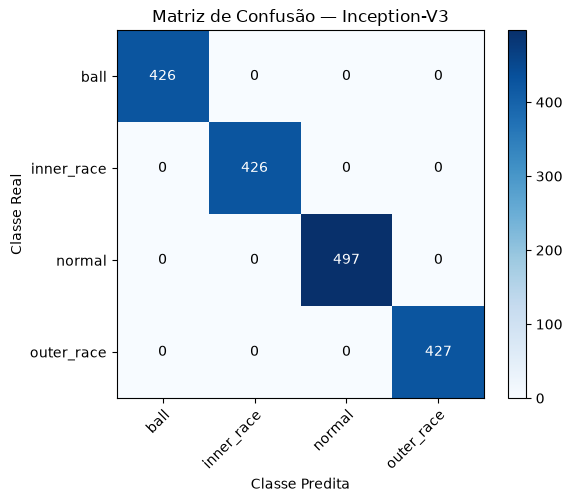

In [3]:
# Treinamento do Inception-v3
res_inception = train_and_evaluate_transfer_model('inception_v3', num_epochs=NUM_EPOCHS, lr=LEARNING_RATE, freeze=False)
resultados['inception_v3'] = res_inception

# --- 1. Curvas de Aprendizado ---
plot_training_curves(res_inception['history'], 'Inception-V3',
                      save_path='../docs/images/training_curves_inception.png')

# --- 2. Relatório de Classificação ---
print('=== RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (INCEPTION-V3) ===')
print(classification_report(res_inception['test_labels'], res_inception['test_preds'], target_names=res_inception['classes'], digits=4))

# --- 3. Matriz de Confusão ---
plot_confusion_matrix(res_inception, 'Inception-V3')

## 4. Experimento 3: EfficientNet-B0

Treinamento, curvas de aprendizado, relatório de classificação e matriz de confusão do **EfficientNet-B0**.

[INFO] EXPERIMENTO TRANSFER LEARNING: EFFICIENTNET_B0 | Freeze=False | Épocas=10 | LR=0.0001
Época [01/10] | Treino Loss: 0.1589 - Acc: 96.43% | Val Loss: 0.0019 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 01/10.
Época [02/10] | Treino Loss: 0.0098 - Acc: 99.82% | Val Loss: 0.0005 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 02/10.
Época [03/10] | Treino Loss: 0.0046 - Acc: 99.92% | Val Loss: 0.0009 - Acc: 100.00% 
Época [04/10] | Treino Loss: 0.0031 - Acc: 99.95% | Val Loss: 0.0002 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 04/10.
Época [05/10] | Treino Loss: 0.0037 - Acc: 99.95% | Val Loss: 0.0001 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 05/10.
Época [06/10] | Treino Loss: 0.0010 - Acc: 99.99% | Val Loss: 0.0000 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 06/10.
Época [07/10] | Treino Loss: 0.0015 - Acc: 99.98% | Val Loss: 0.0000 - Acc: 100.00% 
Época [08/10] | Treino Loss: 0.0013 - Acc: 99.99% | Val Loss: 0.0000 - Acc: 1

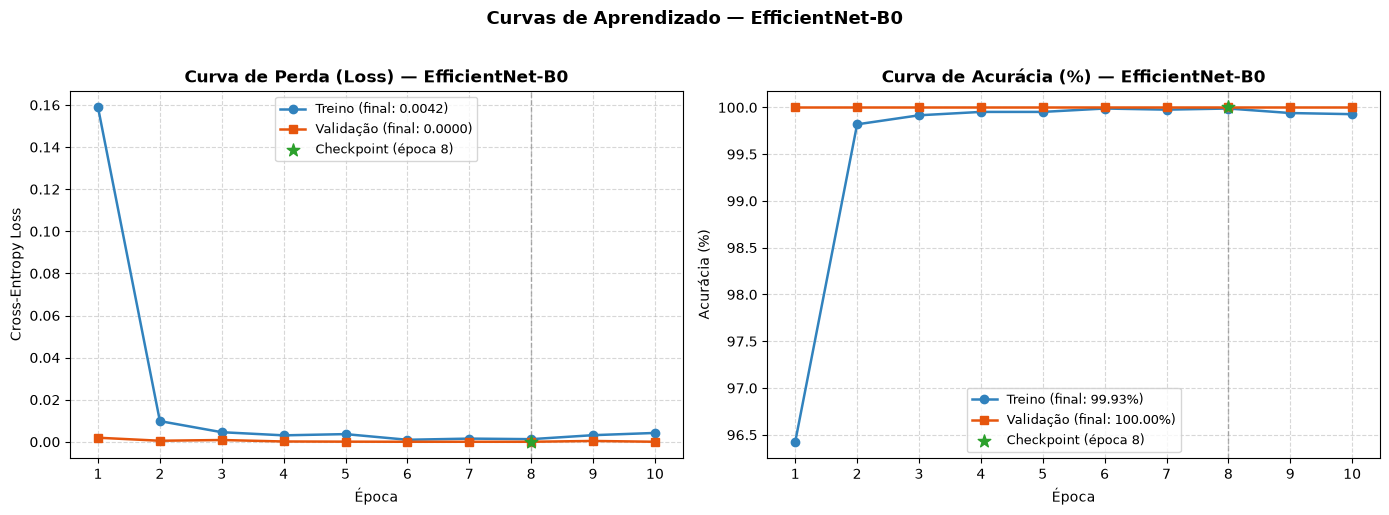

=== RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (EFFICIENTNET-B0) ===
              precision    recall  f1-score   support

        ball     1.0000    1.0000    1.0000       426
  inner_race     1.0000    1.0000    1.0000       426
      normal     1.0000    1.0000    1.0000       497
  outer_race     1.0000    1.0000    1.0000       427

    accuracy                         1.0000      1776
   macro avg     1.0000    1.0000    1.0000      1776
weighted avg     1.0000    1.0000    1.0000      1776



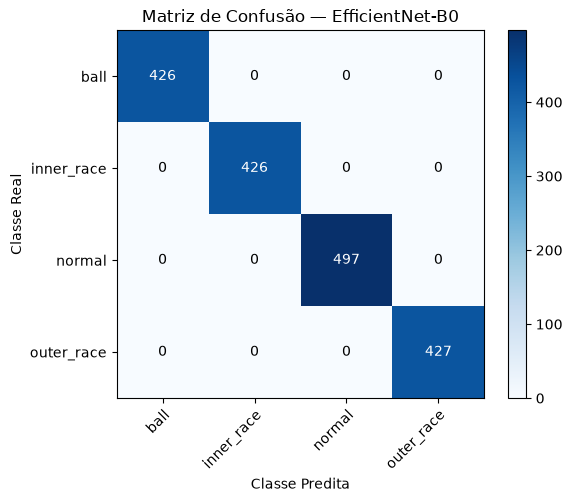

In [4]:
# Treinamento do EfficientNet-B0
res_efficientnet = train_and_evaluate_transfer_model('efficientnet_b0', num_epochs=NUM_EPOCHS, lr=LEARNING_RATE, freeze=False)
resultados['efficientnet_b0'] = res_efficientnet

# --- 1. Curvas de Aprendizado ---
plot_training_curves(res_efficientnet['history'], 'EfficientNet-B0',
                      save_path='../docs/images/training_curves_efficientnet.png')

# --- 2. Relatório de Classificação ---
print('=== RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (EFFICIENTNET-B0) ===')
print(classification_report(res_efficientnet['test_labels'], res_efficientnet['test_preds'], target_names=res_efficientnet['classes'], digits=4))

# --- 3. Matriz de Confusão ---
plot_confusion_matrix(res_efficientnet, 'EfficientNet-B0')

## 5. Tabela Comparativa Geral de Desempenho 



In [5]:
print('================================================================================')
print(' TABELA COMPARATIVA DE MODELOS — DIAGNÓSTICO DE FALHAS EM ROLAMENTOS (TCC) ')
print('================================================================================')
print(f'{"Modelo":<22s} | {"Estratégia":<16s} | {"Acurácia Val (%)":<18s} | {"Acurácia Teste (%)":<18s}')
print('-' * 80)

for nome_modelo, res in resultados.items():
    print(f'{res["model_name"].upper():<22s} | {"Transfer Learning":<16s} | {res["best_val_acc"]:<17.2f}% | {res["test_acc"]:<17.2f}%')
print('================================================================================')

 TABELA COMPARATIVA DE MODELOS — DIAGNÓSTICO DE FALHAS EM ROLAMENTOS (TCC) 
Modelo                 | Estratégia       | Acurácia Val (%)   | Acurácia Teste (%)
--------------------------------------------------------------------------------
RESNET18               | Transfer Learning | 100.00           % | 100.00           %
INCEPTION_V3           | Transfer Learning | 100.00           % | 100.00           %
EFFICIENTNET_B0        | Transfer Learning | 100.00           % | 100.00           %
